# High-Value Order Prediction in E-Commerce Using Machine Learning

## Problem Statement:The objective of this project is to develop a Machine Learning classification model that predicts whether an e-commerce order will be a High-Value Order (Yes/No) based on customer information, product details, purchasing behavior, discounts, shipping details, and profitability metrics. By analyzing historical order data, the model can help businesses identify high-revenue transactions, improve marketing strategies, optimize inventory planning, and enhance overall profitability.

In [18]:
import pandas as pd
import numpy as np
Ecommerce_Data=pd.read_csv("C:/Users/abrau/ML Projects/Python IVY Feb-2024-20260611T164017Z-3-001/Python IVY Feb-2024/My ML Projects/Classification Projects/Ecommerce Dataset/ecommerce_orders_dataset.csv",
                            encoding='latin')
print('Data Before deleting duplicate values:',Ecommerce_Data.shape)  
Ecommerce_Data.drop_duplicates(inplace=True)
print('Data After:deleting duplicate values',Ecommerce_Data.shape)
pd.set_option('display.max_rows',None) 
pd.set_option('display.max_columns',None)  
Ecommerce_Data.head(10)

Data Before deleting duplicate values: (30000, 41)
Data After:deleting duplicate values (30000, 41)


,Order_ID,Customer_ID,Order_Date,Year,Month,Day,Day_Of_Week,Quarter,Customer_Age,Customer_Gender,Country,City,Customer_Segment,Product_ID,Product_Category,Product_Subcategory,Brand,Unit_Price,Quantity,Discount_Percent,Discount_Amount,Coupon_Used,Shipping_Cost,Tax_Amount,Order_Amount,Payment_Method,Device_Type,Traffic_Source,Membership_Status,Shipping_Method,Warehouse_Region,Delivery_Days,Order_Status,Returned,Review_Rating,Customer_Lifetime_Value,Profit_Margin_Percent,Profit_Amount,Season,Holiday_Season,High_Value_Order
0,615717,CUST007322,2023-01-01,2023,1,1,Sunday,1,32,Male,Germany,Dubai,Loyal,PROD02374,Books,Comics,PrimePlus,18.44,3,10,5.53,Yes,15.50,2.91,68.20,Debit Card,Mobile,Social Media,Standard,Express,North,2,Delivered,No,4.4,2144.92,23.10,15.75,Winter,No,No
1,626919,CUST004717,2023-01-01,2023,1,1,Sunday,1,50,Male,France,London,Returning,PROD01378,Sports,Equipment,PrimePlus,46.58,1,40,18.63,Yes,5.87,4.91,38.73,Wallet,Mobile,Email,Standard,Standard,East,9,Delivered,No,4.1,817.17,8.57,3.32,Winter,No,No
2,615781,CUST004415,2023-01-01,2023,1,1,Sunday,1,61,Male,India,Berlin,Returning,PROD01850,Beauty,Skincare,Zenith,62.18,3,35,65.29,Yes,15.91,16.50,153.66,Cash on Delivery,Mobile,Paid Ads,Standard,Express,Central,2,Delivered,No,5.0,541.16,29.72,45.67,Winter,No,No
3,621747,CUST004114,2023-01-01,2023,1,1,Sunday,1,34,Male,United States,Riyadh,Returning,PROD00545,Fashion,Women Clothing,FreshMart,91.06,3,0,0.00,No,9.17,16.02,298.37,Wallet,Desktop,Organic Search,Standard,Standard,South,6,Returned,Yes,3.4,700.49,25.22,75.25,Winter,No,No
4,625881,CUST000145,2023-01-01,2023,1,1,Sunday,1,37,Male,India,Mumbai,Premium,PROD01398,Beauty,Makeup,Zenith,99.44,1,15,14.92,Yes,13.63,7.60,105.75,PayPal,Mobile,Referral,Standard,Express,Central,8,Delivered,No,3.6,2133.77,24.64,26.06,Winter,No,No
5,613497,CUST000940,2023-01-01,2023,1,1,Sunday,1,32,Female,Australia,Sydney,New,PROD01013,Home & Kitchen,Decor,Nova,125.84,3,5,18.88,No,18.83,36.46,413.93,PayPal,Mobile,Social Media,Standard,Express,North,5,Processing,No,4.1,5844.78,30.29,125.38,Winter,No,Yes
6,600746,CUST004139,2023-01-01,2023,1,1,Sunday,1,25,Female,United States,Karachi,Returning,PROD01390,Fashion,Women Clothing,UrbanCo,34.17,3,0,0.00,No,3.44,10.31,116.26,Credit Card,Desktop,Social Media,Gold,Standard,West,6,Delivered,No,5.0,1178.52,27.91,32.45,Winter,No,No
7,604774,CUST000543,2023-01-01,2023,1,1,Sunday,1,38,Female,Canada,Sydney,Premium,PROD00106,Fashion,Women Clothing,Trendify,149.41,1,30,44.82,Yes,6.35,5.94,116.88,Cash on Delivery,Tablet,Organic Search,Silver,Standard,East,6,Delivered,No,4.1,2535.68,10.14,11.85,Winter,No,No
8,600323,CUST003309,2023-01-01,2023,1,1,Sunday,1,48,Female,Germany,Karachi,Returning,PROD02359,Home & Kitchen,Cookware,Zenith,100.86,1,0,0.00,No,2.36,3.10,106.32,Debit Card,Mobile,Direct,Standard,Standard,North,5,Delivered,No,3.4,598.88,17.93,19.06,Winter,No,No
9,608449,CUST006419,2023-01-01,2023,1,1,Sunday,1,31,Other,Saudi Arabia,Karachi,Returning,PROD00312,Beauty,Makeup,Trendify,35.21,5,5,8.80,No,12.32,5.71,185.28,Cash on Delivery,Mobile,Social Media,Silver,Standard,North,6,Shipped,No,4.5,1050.17,31.95,59.20,Winter,No,No


In [19]:
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)

### Target Variable:High_Value_Order

## Exploratory Data Analysis

<Axes: xlabel='High_Value_Order'>

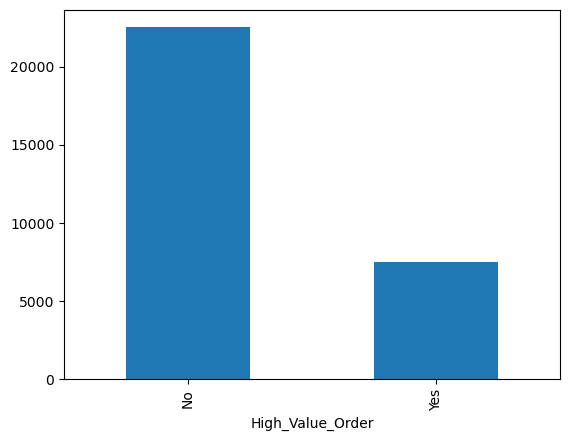

In [20]:
Ecommerce_Data.groupby('High_Value_Order').size().plot(kind='bar')

In [21]:
Ecommerce_Data.columns

Index(['Order_ID', 'Customer_ID', 'Order_Date', 'Year', 'Month', 'Day',
       'Day_Of_Week', 'Quarter', 'Customer_Age', 'Customer_Gender', 'Country',
       'City', 'Customer_Segment', 'Product_ID', 'Product_Category',
       'Product_Subcategory', 'Brand', 'Unit_Price', 'Quantity',
       'Discount_Percent', 'Discount_Amount', 'Coupon_Used', 'Shipping_Cost',
       'Tax_Amount', 'Order_Amount', 'Payment_Method', 'Device_Type',
       'Traffic_Source', 'Membership_Status', 'Shipping_Method',
       'Warehouse_Region', 'Delivery_Days', 'Order_Status', 'Returned',
       'Review_Rating', 'Customer_Lifetime_Value', 'Profit_Margin_Percent',
       'Profit_Amount', 'Season', 'Holiday_Season', 'High_Value_Order'],
      dtype='object')

In [22]:
Ecommerce_Data.nunique()

Order_ID                   30000
Customer_ID                 8683
Order_Date                  1461
Year                           4
Month                         12
Day                           31
Day_Of_Week                    7
Quarter                        4
Customer_Age                  58
Customer_Gender                3
Country                       10
City                          10
Customer_Segment               4
Product_ID                  2500
Product_Category               8
Product_Subcategory           32
Brand                         10
Unit_Price                 16271
Quantity                      11
Discount_Percent               9
Discount_Amount            10098
Coupon_Used                    2
Shipping_Cost               2731
Tax_Amount                  8125
Order_Amount               22962
Payment_Method                 6
Device_Type                    3
Traffic_Source                 6
Membership_Status              4
Shipping_Method                4
Warehouse_

In [23]:
droppingthecolumns=['Order_ID'  ,'Customer_ID', 'Product_ID' ]
Ecommerce_Data.drop(droppingthecolumns,axis=1,inplace=True)

In [24]:

Ecommerce_Data.drop('Order_Date',axis=1,inplace=True)

In [25]:
Ecommerce_Data.head()

,Year,Month,Day,Day_Of_Week,Quarter,Customer_Age,Customer_Gender,Country,City,Customer_Segment,Product_Category,Product_Subcategory,Brand,Unit_Price,Quantity,Discount_Percent,Discount_Amount,Coupon_Used,Shipping_Cost,Tax_Amount,Order_Amount,Payment_Method,Device_Type,Traffic_Source,Membership_Status,Shipping_Method,Warehouse_Region,Delivery_Days,Order_Status,Returned,Review_Rating,Customer_Lifetime_Value,Profit_Margin_Percent,Profit_Amount,Season,Holiday_Season,High_Value_Order
0,2023,1,1,Sunday,1,32,Male,Germany,Dubai,Loyal,Books,Comics,PrimePlus,18.44,3,10,5.53,Yes,15.50,2.91,68.20,Debit Card,Mobile,Social Media,Standard,Express,North,2,Delivered,No,4.4,2144.92,23.10,15.75,Winter,No,No
1,2023,1,1,Sunday,1,50,Male,France,London,Returning,Sports,Equipment,PrimePlus,46.58,1,40,18.63,Yes,5.87,4.91,38.73,Wallet,Mobile,Email,Standard,Standard,East,9,Delivered,No,4.1,817.17,8.57,3.32,Winter,No,No
2,2023,1,1,Sunday,1,61,Male,India,Berlin,Returning,Beauty,Skincare,Zenith,62.18,3,35,65.29,Yes,15.91,16.50,153.66,Cash on Delivery,Mobile,Paid Ads,Standard,Express,Central,2,Delivered,No,5.0,541.16,29.72,45.67,Winter,No,No
3,2023,1,1,Sunday,1,34,Male,United States,Riyadh,Returning,Fashion,Women Clothing,FreshMart,91.06,3,0,0.00,No,9.17,16.02,298.37,Wallet,Desktop,Organic Search,Standard,Standard,South,6,Returned,Yes,3.4,700.49,25.22,75.25,Winter,No,No
4,2023,1,1,Sunday,1,37,Male,India,Mumbai,Premium,Beauty,Makeup,Zenith,99.44,1,15,14.92,Yes,13.63,7.60,105.75,PayPal,Mobile,Referral,Standard,Express,Central,8,Delivered,No,3.6,2133.77,24.64,26.06,Winter,No,No


In [26]:
Ecommerce_Data.nunique()

Year                           4
Month                         12
Day                           31
Day_Of_Week                    7
Quarter                        4
Customer_Age                  58
Customer_Gender                3
Country                       10
City                          10
Customer_Segment               4
Product_Category               8
Product_Subcategory           32
Brand                         10
Unit_Price                 16271
Quantity                      11
Discount_Percent               9
Discount_Amount            10098
Coupon_Used                    2
Shipping_Cost               2731
Tax_Amount                  8125
Order_Amount               22962
Payment_Method                 6
Device_Type                    3
Traffic_Source                 6
Membership_Status              4
Shipping_Method                4
Warehouse_Region               5
Delivery_Days                 14
Order_Status                   5
Returned                       2
Review_Rat

### CategoricalCols=['Year', 'Month','Day_Of_Week', 'Quarter','Customer_Gender','Country', 'City','Customer_Segment','Product_Category','Product_Subcategory','Brand','Quantity','Discount_Percent','Coupon_Used','Payment_Method',
'Device_Type','Traffic_Source','Membership_Status','Shipping_Method','Warehouse_Region','Delivery_Days','Order_Status','Returned',
'Season','Holiday_Season','High_Value_Order'
]
### ContinousCols=['Customer_Age','Unit_Price', 'Discount_Amount','Shipping_Cost','Tax_Amount','Order_Amount','Customer_Lifetime_Value','Profit_Margin_Percent','Profit_Margin_Percent']

In [27]:
Ecommerce_Data.shape

(30000, 37)

In [28]:
Ecommerce_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 37 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Year                     30000 non-null  int64  
 1   Month                    30000 non-null  int64  
 2   Day                      30000 non-null  int64  
 3   Day_Of_Week              30000 non-null  object 
 4   Quarter                  30000 non-null  int64  
 5   Customer_Age             30000 non-null  int64  
 6   Customer_Gender          30000 non-null  object 
 7   Country                  30000 non-null  object 
 8   City                     30000 non-null  object 
 9   Customer_Segment         30000 non-null  object 
 10  Product_Category         30000 non-null  object 
 11  Product_Subcategory      30000 non-null  object 
 12  Brand                    30000 non-null  object 
 13  Unit_Price               30000 non-null  float64
 14  Quantity              

In [29]:
Ecommerce_Data.describe()

,Year,Month,Day,Quarter,Customer_Age,Unit_Price,Quantity,Discount_Percent,Discount_Amount,Shipping_Cost,Tax_Amount,Order_Amount,Delivery_Days,Review_Rating,Customer_Lifetime_Value,Profit_Margin_Percent,Profit_Amount
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,2024.494700,6.531500,15.723600,2.507000,36.370300,126.820148,3.080667,12.618667,49.432742,10.316779,29.143818,379.001466,4.436667,4.047990,4372.340178,21.969056,73.863876
std,1.118815,3.460955,8.779714,1.118806,11.315534,172.675272,1.450412,11.085201,114.401634,5.890701,49.562251,585.405554,2.349363,0.686492,6811.029394,9.079134,113.480736
min,2023.000000,1.000000,1.000000,1.000000,18.000000,3.840000,1.000000,0.000000,0.000000,0.000000,0.260000,6.670000,0.000000,1.000000,20.000000,3.000000,0.270000
25%,2023.000000,4.000000,8.000000,2.000000,28.000000,29.880000,2.000000,0.000000,0.000000,6.020000,5.270000,82.947500,3.000000,3.600000,1029.637500,15.680000,16.640000
50%,2024.000000,7.000000,16.000000,3.000000,36.000000,60.670000,3.000000,10.000000,13.470000,9.000000,12.065000,171.030000,4.000000,4.100000,2073.365000,21.870000,36.995000
75%,2025.000000,10.000000,23.000000,4.000000,44.000000,128.572500,4.000000,20.000000,44.822500,14.220000,29.442500,388.190000,6.000000,4.600000,4482.105000,28.180000,82.125000
max,2026.000000,12.000000,31.000000,4.000000,75.000000,1940.000000,11.000000,40.000000,2623.900000,32.600000,1043.160000,10314.270000,13.000000,5.000000,50000.000000,56.610000,2480.540000


## Uni Variate Analysis by Bar Charts

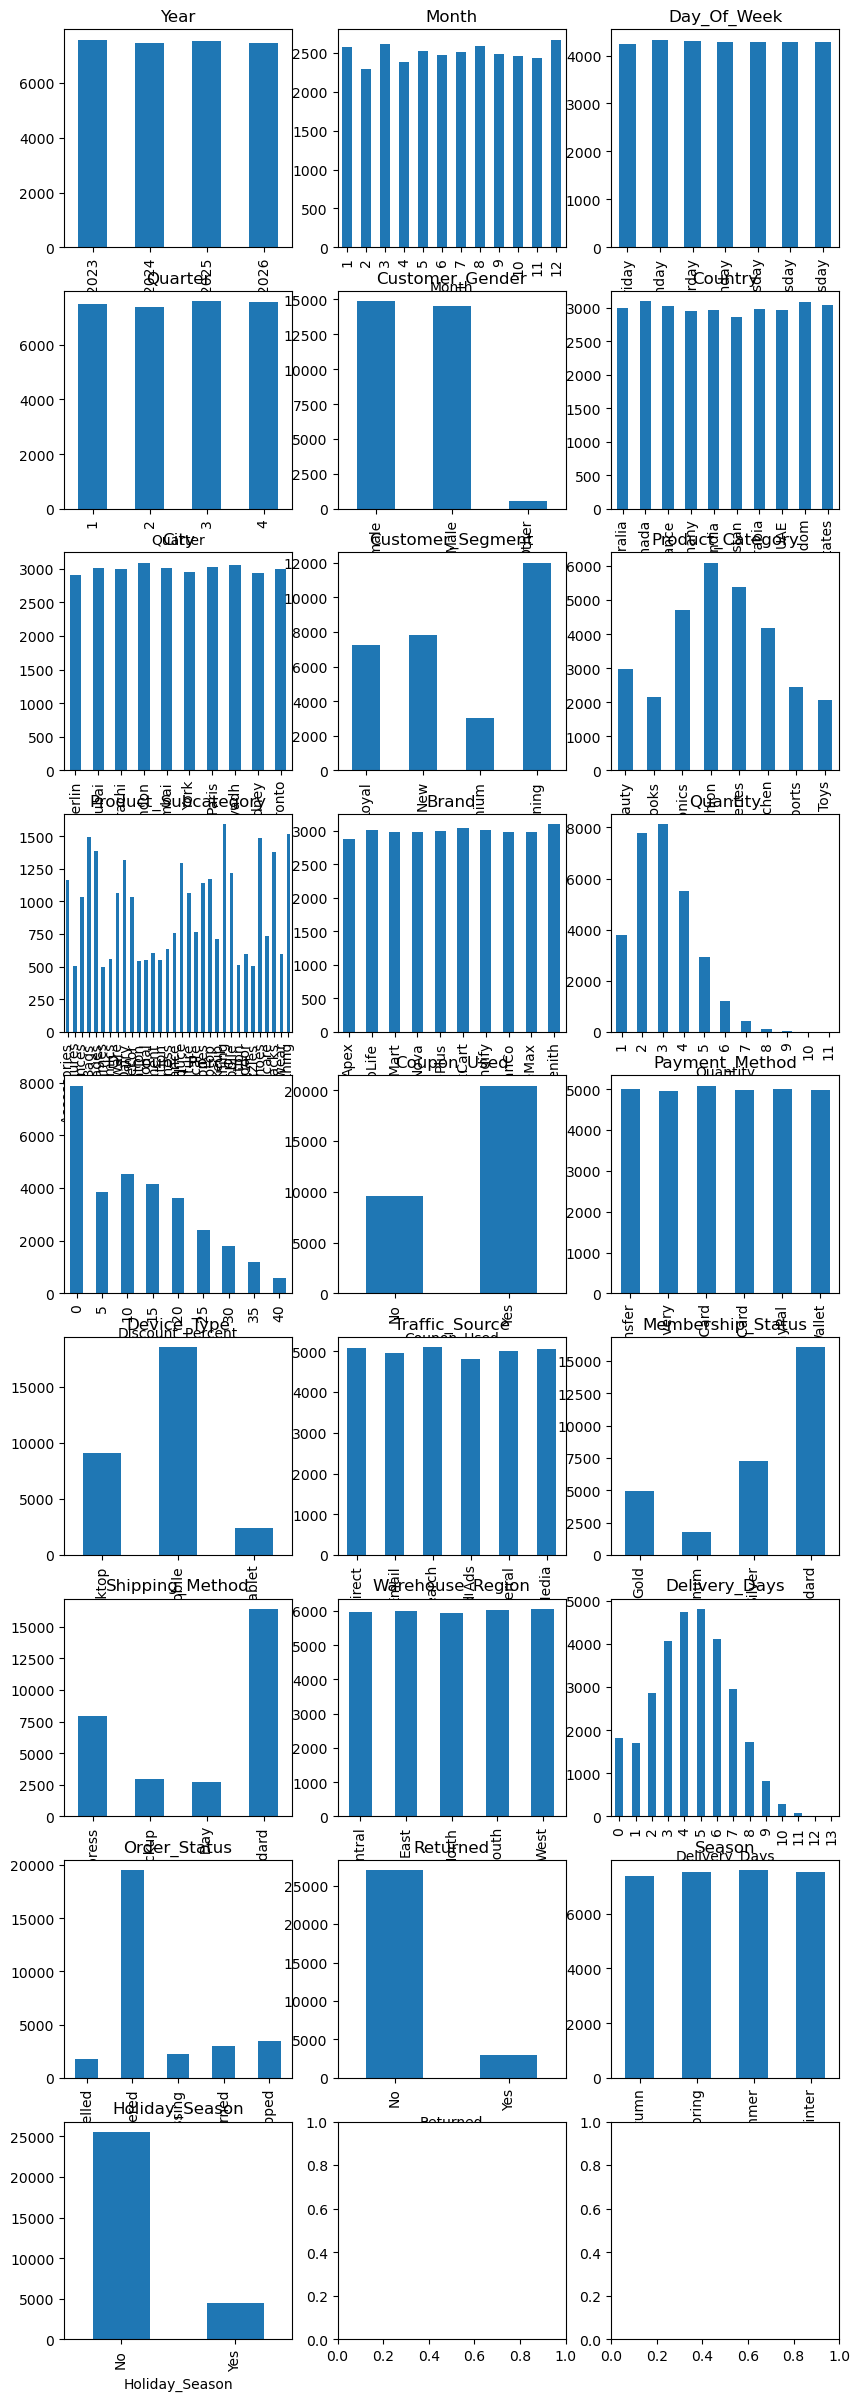

In [30]:
CategoricalCols=['Year', 'Month','Day_Of_Week', 'Quarter','Customer_Gender','Country', 'City','Customer_Segment','Product_Category','Product_Subcategory','Brand','Quantity','Discount_Percent','Coupon_Used','Payment_Method',
'Device_Type','Traffic_Source','Membership_Status','Shipping_Method','Warehouse_Region','Delivery_Days','Order_Status','Returned', 'Season','Holiday_Season']
import matplotlib.pyplot as plt
fig, subplots=plt.subplots(9,3,figsize=(10,30))
subplots=subplots.flatten()
for cols , no_of_cols in zip(CategoricalCols,range(len(CategoricalCols))):
    Ecommerce_Data.groupby(cols).size().plot(kind='bar',ax=subplots[no_of_cols],title=cols)

### No need of imbalance treatment

## Uni Variate Analysis by Histogram

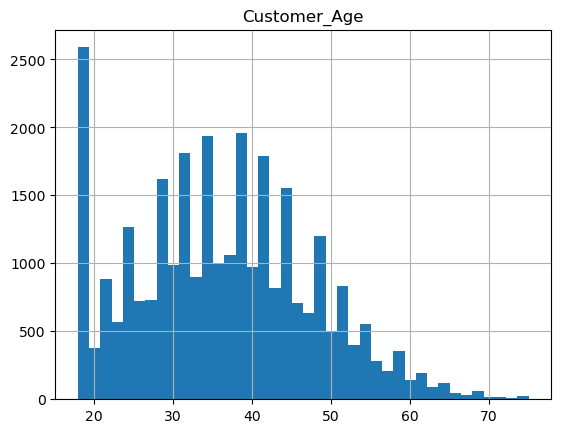

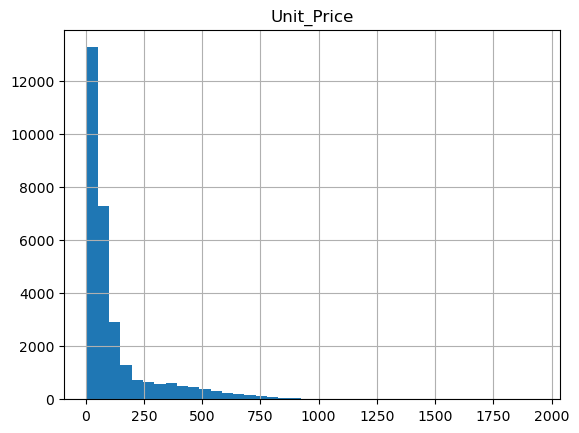

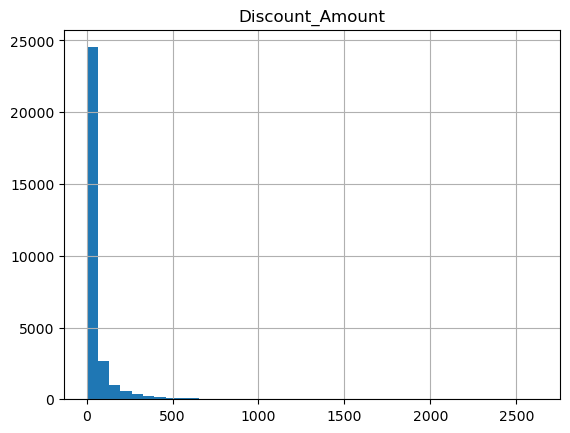

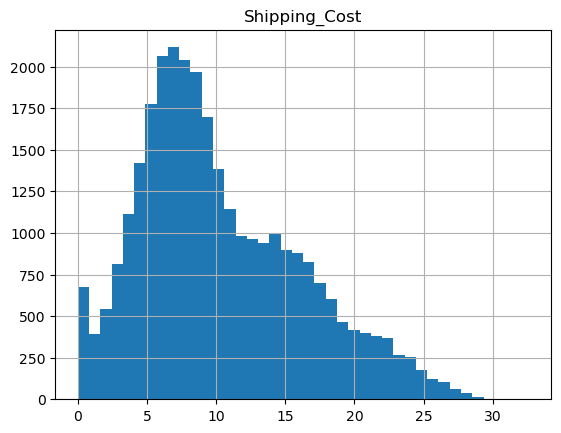

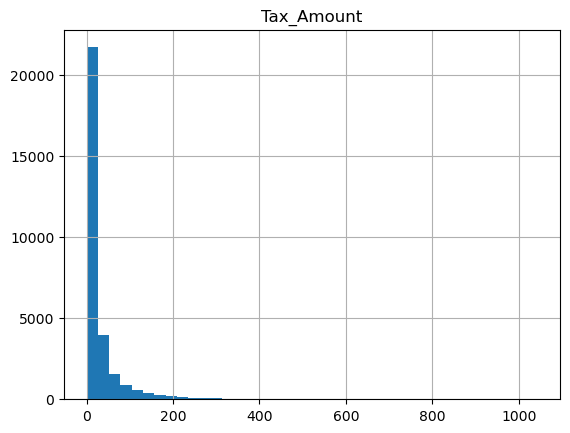

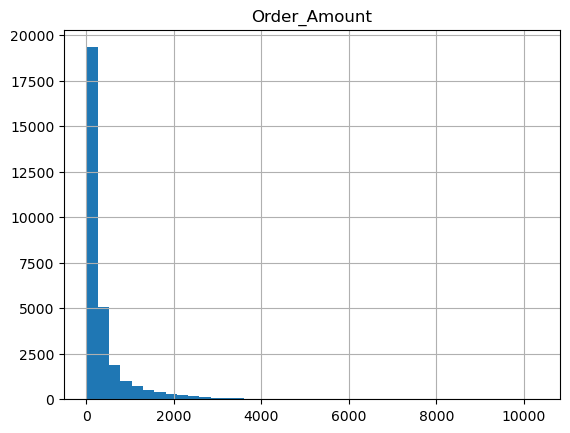

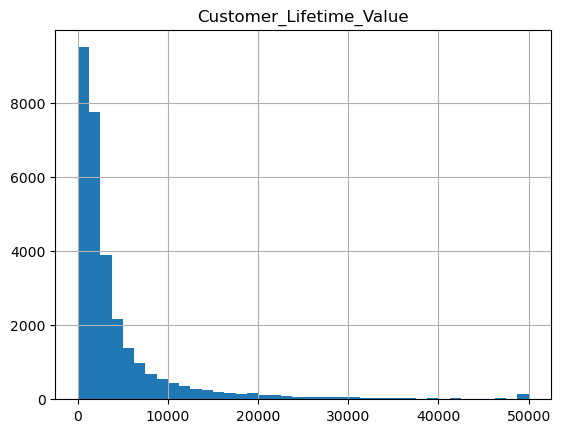

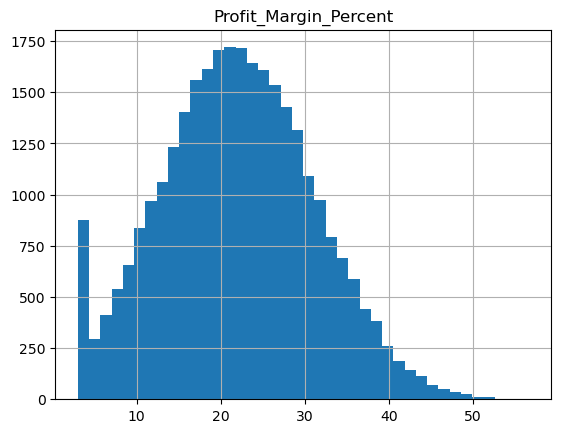

In [31]:
ContinousColumns=['Customer_Age','Unit_Price', 'Discount_Amount','Shipping_Cost','Tax_Amount','Order_Amount','Customer_Lifetime_Value','Profit_Margin_Percent']
for cols in ContinousColumns:
    Ecommerce_Data.hist(cols,bins=40)


## No need of  Outlier Treatment

### No need of missing value treatment

In [32]:
HeartDiseaseData.isnull().sum()

NameError: name 'HeartDiseaseData' is not defined

## Continous Vs Categorical Bivariate Analysis by Box Plots

In [ ]:
ContinousCols=['Customer_Age','Unit_Price', 'Discount_Amount','Shipping_Cost','Tax_Amount','Order_Amount','Customer_Lifetime_Value','Profit_Margin_Percent']
import matplotlib.pyplot as plt
fig,subplots=plt.subplots(3,3,figsize=(15,12))
subplots=subplots.flatten()
for cols, no_of_cols in zip(ContinousCols,range(len(ContinousCols))):
    Ecommerce_Data.boxplot(column=cols,by='High_Value_Order',vert=True,ax=subplots[no_of_cols])

## Statistical Feature Selection by Anova Function

In [ ]:
ContinousCols=['Customer_Age','Unit_Price', 'Discount_Amount','Shipping_Cost','Tax_Amount','Order_Amount','Customer_Lifetime_Value','Profit_Margin_Percent']
def function_anova(inpData,ContinousCols,targetVariable):
    from scipy.stats import f_oneway
    SelectedPredictors=[]
    for cols in ContinousCols:
        CategoricalGroupLists=inpData.groupby(targetVariable)[cols].apply(list)
        AnovaResults=f_oneway(*CategoricalGroupLists)
        if AnovaResults[1]<0.05:
            print(cols,' is correlated with High_Value_Order and p value is:',AnovaResults[1]) 
            SelectedPredictors.append(cols)
        else:
            print(cols,' is not correlated with High_Value_Order and p value is:',AnovaResults[1]) 
    return SelectedPredictors
function_anova(inpData=Ecommerce_Data,ContinousCols=['Customer_Age','Unit_Price', 'Discount_Amount','Shipping_Cost','Tax_Amount','Order_Amount','Customer_Lifetime_Value','Profit_Margin_Percent'],
               targetVariable='High_Value_Order')
  

## Categorical Vs Categorical Bivariate Analysis by Grouped Bar Charts

In [ ]:
CategoricalCols=['Year', 'Month','Day_Of_Week', 'Quarter','Customer_Gender','Country', 'City','Customer_Segment','Product_Category','Product_Subcategory','Brand','Quantity','Discount_Percent','Coupon_Used','Payment_Method',
'Device_Type','Traffic_Source','Membership_Status','Shipping_Method','Warehouse_Region','Delivery_Days','Order_Status','Returned', 'Season','Holiday_Season']
import matplotlib.pyplot as plt
fig,subplots=plt.subplots(9,3,figsize=(15,30))
subplots=subplots.flatten()
for cols, no_of_cols in zip(CategoricalCols,range(len(CategoricalCols))):
    crosstabresults=pd.crosstab(columns=Ecommerce_Data['High_Value_Order'],index=Ecommerce_Data[cols])
    crosstabresults.plot.bar(color=['red','green'],ax=subplots[no_of_cols])

## Statistical Feature Selection by Chi2 Function

In [ ]:
CategoricalCols=['Year', 'Month','Day_Of_Week', 'Quarter','Customer_Gender','Country', 'City','Customer_Segment','Product_Category','Product_Subcategory','Brand','Quantity','Discount_Percent','Coupon_Used','Payment_Method',
'Device_Type','Traffic_Source','Membership_Status','Shipping_Method','Warehouse_Region','Delivery_Days','Order_Status','Returned', 'Season','Holiday_Season']
def Chis2_test_function(inpData, CategoricalCols,targetVariable):
    SelectedPredictors=[]
    from scipy.stats import chi2_contingency
    for cols in CategoricalCols: 
        crosstabresults=pd.crosstab(columns=inpData[targetVariable],index=Ecommerce_Data[cols])
        chi2_results=chi2_contingency(crosstabresults)
        if chi2_results[1]<0.05:
            print(cols,' is correlated with High_Value_Order and p value is:',chi2_results[1])
            SelectedPredictors.append(cols)
        else:
            print(cols,' is not correlated with High_Value_Order and p value is:',chi2_results[1])
    return SelectedPredictors
Chis2_test_function(inpData=Ecommerce_Data, CategoricalCols=['Year', 'Month','Day_Of_Week', 'Quarter','Customer_Gender','Country', 'City','Customer_Segment','Product_Category','Product_Subcategory','Brand','Quantity','Discount_Percent','Coupon_Used','Payment_Method',
'Device_Type','Traffic_Source','Membership_Status','Shipping_Method','Warehouse_Region','Delivery_Days','Order_Status','Returned', 'Season','Holiday_Season'],targetVariable='High_Value_Order')  


## Selecting final predictors for Machine Learning

In [33]:
SelectedColumns=['Product_Category',
 'Product_Subcategory',
 'Quantity',
 'Discount_Percent',
 'Coupon_Used',
 'Device_Type',
 'Shipping_Method',
 'Season','Unit_Price',
 'Discount_Amount',
 'Shipping_Cost',
 'Tax_Amount',
 'Customer_Lifetime_Value',
 'Profit_Margin_Percent']
DataForML_Ecommerce_Data=Ecommerce_Data[SelectedColumns]
DataForML_Ecommerce_Data.to_pickle('DataForML_EcommerceData.pkl')
DataForML_Ecommerce_Data=pd.read_pickle('DataForML_EcommerceData.pkl')
DataForML_Ecommerce_Data.head()




,Product_Category,Product_Subcategory,Quantity,Discount_Percent,Coupon_Used,Device_Type,Shipping_Method,Season,Unit_Price,Discount_Amount,Shipping_Cost,Tax_Amount,Customer_Lifetime_Value,Profit_Margin_Percent
0,Books,Comics,3,10,Yes,Mobile,Express,Winter,18.44,5.53,15.50,2.91,2144.92,23.10
1,Sports,Equipment,1,40,Yes,Mobile,Standard,Winter,46.58,18.63,5.87,4.91,817.17,8.57
2,Beauty,Skincare,3,35,Yes,Mobile,Express,Winter,62.18,65.29,15.91,16.50,541.16,29.72
3,Fashion,Women Clothing,3,0,No,Desktop,Standard,Winter,91.06,0.00,9.17,16.02,700.49,25.22
4,Beauty,Makeup,1,15,Yes,Mobile,Express,Winter,99.44,14.92,13.63,7.60,2133.77,24.64


## Data Pre-processing for Machine Learning
## Converting the nominal variable to numeric using get_dummies()

In [34]:
DataForML_Ecommerce_Data=pd.get_dummies(DataForML_Ecommerce_Data)
DataForML_Ecommerce_Data.head()

,Quantity,Discount_Percent,Unit_Price,Discount_Amount,Shipping_Cost,Tax_Amount,Customer_Lifetime_Value,Profit_Margin_Percent,Product_Category_Beauty,Product_Category_Books,Product_Category_Electronics,Product_Category_Fashion,Product_Category_Groceries,Product_Category_Home & Kitchen,Product_Category_Sports,Product_Category_Toys,Product_Subcategory_Accessories,Product_Subcategory_Action Figures,Product_Subcategory_Appliances,Product_Subcategory_Bags,Product_Subcategory_Beverages,Product_Subcategory_Board Games,Product_Subcategory_Comics,Product_Subcategory_Cookware,Product_Subcategory_Dairy,Product_Subcategory_Decor,Product_Subcategory_Education,Product_Subcategory_Educational,Product_Subcategory_Equipment,Product_Subcategory_Fiction,Product_Subcategory_Fitness,Product_Subcategory_Fragrance,Product_Subcategory_Fresh Produce,Product_Subcategory_Furniture,Product_Subcategory_Haircare,Product_Subcategory_Headphones,Product_Subcategory_Laptop,Product_Subcategory_Makeup,Product_Subcategory_Men Clothing,Product_Subcategory_Mobile,Product_Subcategory_Non-Fiction,Product_Subcategory_Outdoor,Product_Subcategory_Puzzles,Product_Subcategory_Shoes,Product_Subcategory_Skincare,Product_Subcategory_Snacks,Product_Subcategory_Sportswear,Product_Subcategory_Women Clothing,Coupon_Used_No,Coupon_Used_Yes,Device_Type_Desktop,Device_Type_Mobile,Device_Type_Tablet,Shipping_Method_Express,Shipping_Method_Pickup,Shipping_Method_Same Day,Shipping_Method_Standard,Season_Autumn,Season_Spring,Season_Summer,Season_Winter
0,3,10,18.44,5.53,15.50,2.91,2144.92,23.10,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,True,False,False,False,False,False,False,True
1,1,40,46.58,18.63,5.87,4.91,817.17,8.57,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,True,False,False,False,True
2,3,35,62.18,65.29,15.91,16.50,541.16,29.72,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,True,False,False,False,False,False,False,True
3,3,0,91.06,0.00,9.17,16.02,700.49,25.22,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,True,False,False,False,False,False,True,False,False,False,True
4,1,15,99.44,14.92,13.63,7.60,2133.77,24.64,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,True,False,False,False,False,False,False,True


## Converting the binary nominal variable to numeric using 1/0 mapping

In [35]:
DataForML_Ecommerce_Data.replace({True:1,False:0},inplace=True)

C:\Users\abrau\AppData\Local\Temp\ipykernel_61608\1122198499.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  DataForML_Ecommerce_Data.replace({True:1,False:0},inplace=True)


In [ ]:
DataForML_Ecommerce_Data.head()

In [36]:
DataForML_Ecommerce_Data['High_Value_Order']=Ecommerce_Data['High_Value_Order']


In [37]:
DataForML_Ecommerce_Data['High_Value_Order'].replace({'Yes':1,'No':0},inplace=True)

C:\Users\abrau\AppData\Local\Temp\ipykernel_61608\3649090975.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  DataForML_Ecommerce_Data['High_Value_Order'].replace({'Yes':1,'No':0},inplace=True)
C:\Users\abrau\AppData\Local\Temp\ipykernel_61608\3649090975.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting',

## Splitting the data into Training and Testing sample

<Axes: xlabel='High_Value_Order'>

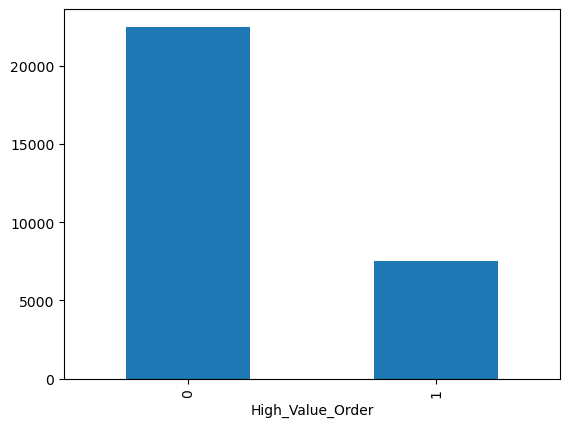

In [38]:
DataForML_Ecommerce_Data.groupby('High_Value_Order').size().plot(kind='bar')

In [63]:
DataForML_Ecommerce_Data.head(10)

,Quantity,Discount_Percent,Unit_Price,Discount_Amount,Shipping_Cost,Tax_Amount,Customer_Lifetime_Value,Profit_Margin_Percent,Product_Category_Beauty,Product_Category_Books,Product_Category_Electronics,Product_Category_Fashion,Product_Category_Groceries,Product_Category_Home & Kitchen,Product_Category_Sports,Product_Category_Toys,Product_Subcategory_Accessories,Product_Subcategory_Action Figures,Product_Subcategory_Appliances,Product_Subcategory_Bags,Product_Subcategory_Beverages,Product_Subcategory_Board Games,Product_Subcategory_Comics,Product_Subcategory_Cookware,Product_Subcategory_Dairy,Product_Subcategory_Decor,Product_Subcategory_Education,Product_Subcategory_Educational,Product_Subcategory_Equipment,Product_Subcategory_Fiction,Product_Subcategory_Fitness,Product_Subcategory_Fragrance,Product_Subcategory_Fresh Produce,Product_Subcategory_Furniture,Product_Subcategory_Haircare,Product_Subcategory_Headphones,Product_Subcategory_Laptop,Product_Subcategory_Makeup,Product_Subcategory_Men Clothing,Product_Subcategory_Mobile,Product_Subcategory_Non-Fiction,Product_Subcategory_Outdoor,Product_Subcategory_Puzzles,Product_Subcategory_Shoes,Product_Subcategory_Skincare,Product_Subcategory_Snacks,Product_Subcategory_Sportswear,Product_Subcategory_Women Clothing,Coupon_Used_No,Coupon_Used_Yes,Device_Type_Desktop,Device_Type_Mobile,Device_Type_Tablet,Shipping_Method_Express,Shipping_Method_Pickup,Shipping_Method_Same Day,Shipping_Method_Standard,Season_Autumn,Season_Spring,Season_Summer,Season_Winter,High_Value_Order
0,3,10,18.44,5.53,15.50,2.91,2144.92,23.10,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,1,0
1,1,40,46.58,18.63,5.87,4.91,817.17,8.57,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,1,0
2,3,35,62.18,65.29,15.91,16.50,541.16,29.72,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,1,0
3,3,0,91.06,0.00,9.17,16.02,700.49,25.22,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,1,0,0,0,1,0
4,1,15,99.44,14.92,13.63,7.60,2133.77,24.64,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,1,0
5,3,5,125.84,18.88,18.83,36.46,5844.78,30.29,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,1
6,3,0,34.17,0.00,3.44,10.31,1178.52,27.91,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,1,0,0,0,1,0
7,1,30,149.41,44.82,6.35,5.94,2535.68,10.14,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,1,0,0,0,1,0
8,1,0,100.86,0.00,2.36,3.10,598.88,17.93,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0
9,5,5,35.21,8.80,12.32,5.71,1050.17,31.95,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0


In [57]:
DataForML_Ecommerce_Data.shape

(30000, 62)

In [ ]:
DataForML_Ecommerce_Data.info()

In [158]:
DataForML_Ecommerce_Data.columns

Index(['Quantity', 'Discount_Percent', 'Unit_Price', 'Discount_Amount',
       'Shipping_Cost', 'Tax_Amount', 'Customer_Lifetime_Value',
       'Profit_Margin_Percent', 'Product_Category_Beauty',
       'Product_Category_Books', 'Product_Category_Electronics',
       'Product_Category_Fashion', 'Product_Category_Groceries',
       'Product_Category_Home & Kitchen', 'Product_Category_Sports',
       'Product_Category_Toys', 'Product_Subcategory_Accessories',
       'Product_Subcategory_Action Figures', 'Product_Subcategory_Appliances',
       'Product_Subcategory_Bags', 'Product_Subcategory_Beverages',
       'Product_Subcategory_Board Games', 'Product_Subcategory_Comics',
       'Product_Subcategory_Cookware', 'Product_Subcategory_Dairy',
       'Product_Subcategory_Decor', 'Product_Subcategory_Education',
       'Product_Subcategory_Educational', 'Product_Subcategory_Equipment',
       'Product_Subcategory_Fiction', 'Product_Subcategory_Fitness',
       'Product_Subcategory_Fragrance'

In [39]:
predictors=['Quantity', 'Discount_Percent', 'Unit_Price', 'Discount_Amount',
       'Shipping_Cost', 'Tax_Amount', 'Customer_Lifetime_Value',
       'Profit_Margin_Percent', 'Product_Category_Beauty',
       'Product_Category_Books', 'Product_Category_Electronics',
       'Product_Category_Fashion', 'Product_Category_Groceries',
       'Product_Category_Home & Kitchen', 'Product_Category_Sports',
       'Product_Category_Toys', 'Product_Subcategory_Accessories',
       'Product_Subcategory_Action Figures', 'Product_Subcategory_Appliances',
       'Product_Subcategory_Bags', 'Product_Subcategory_Beverages',
       'Product_Subcategory_Board Games', 'Product_Subcategory_Comics',
       'Product_Subcategory_Cookware', 'Product_Subcategory_Dairy',
       'Product_Subcategory_Decor', 'Product_Subcategory_Education',
       'Product_Subcategory_Educational', 'Product_Subcategory_Equipment',
       'Product_Subcategory_Fiction', 'Product_Subcategory_Fitness',
       'Product_Subcategory_Fragrance', 'Product_Subcategory_Fresh Produce',
       'Product_Subcategory_Furniture', 'Product_Subcategory_Haircare',
       'Product_Subcategory_Headphones', 'Product_Subcategory_Laptop',
       'Product_Subcategory_Makeup', 'Product_Subcategory_Men Clothing',
       'Product_Subcategory_Mobile', 'Product_Subcategory_Non-Fiction',
       'Product_Subcategory_Outdoor', 'Product_Subcategory_Puzzles',
       'Product_Subcategory_Shoes', 'Product_Subcategory_Skincare',
       'Product_Subcategory_Snacks', 'Product_Subcategory_Sportswear',
       'Product_Subcategory_Women Clothing', 'Coupon_Used_No',
       'Coupon_Used_Yes', 'Device_Type_Desktop', 'Device_Type_Mobile',
       'Device_Type_Tablet', 'Shipping_Method_Express',
       'Shipping_Method_Pickup', 'Shipping_Method_Same Day',
       'Shipping_Method_Standard', 'Season_Autumn', 'Season_Spring',
       'Season_Summer', 'Season_Winter']
targetVariable= 'High_Value_Order'
X=DataForML_Ecommerce_Data[predictors].values
y=DataForML_Ecommerce_Data[targetVariable].values 
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=45,test_size=0.2)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape) 
print(y_test.shape)

(24000, 61)
(24000,)
(6000, 61)
(6000,)


In [ ]:
X_train[0:5]

In [62]:
y_train[0:5]

array([0, 0, 0, 1, 0])

## Logistic Regression

In [40]:
from sklearn.linear_model import LogisticRegression
#'newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'
clf=LogisticRegression(C=2,penalty='l2',solver='newton-cg')
LOG=clf.fit(X_train,y_train)
prediction=LOG.predict(X_test) 
from sklearn import metrics
print(metrics.classification_report(y_test,prediction))
print(metrics.confusion_matrix(y_test,prediction))
F1_Score=metrics.f1_score(y_test,prediction,average='weighted')
print('Sample Data Accuracy:',np.round((F1_Score),2)*100,'%')
from sklearn.model_selection import cross_val_score
AccuracyValues=cross_val_score(LOG,X,y,cv=5,scoring='f1_weighted')
print(AccuracyValues)
print('Final Accuracy of the Model:',np.round(np.mean(AccuracyValues),2)*100,'%')

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      4501
           1       0.96      0.95      0.96      1499

    accuracy                           0.98      6000
   macro avg       0.97      0.97      0.97      6000
weighted avg       0.98      0.98      0.98      6000

[[4440   61]
 [  72 1427]]
Sample Data Accuracy: 98.0 %
[0.97746726 0.97775055 0.97762661 0.97439889 0.9782994 ]
Final Accuracy of the Model: 98.0 %


## Decision Tree

              precision    recall  f1-score   support

           0       0.97      0.96      0.97      4501
           1       0.90      0.90      0.90      1499

    accuracy                           0.95      6000
   macro avg       0.93      0.93      0.93      6000
weighted avg       0.95      0.95      0.95      6000

[[4343  158]
 [ 144 1355]]
Sample Data Accuaracy: 95.0 %
[0.94862083 0.9433071  0.94655323 0.95088225 0.94817242]
Final Accuracy of the Model: 95.0 %


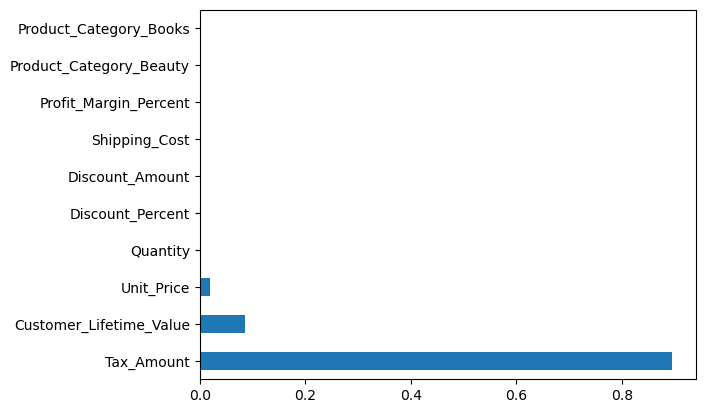

In [164]:
from sklearn import tree
clf=tree.DecisionTreeClassifier(max_depth=3,criterion='gini')
DTree=clf.fit(X_train,y_train)
prediction=DTree.predict(X_test)
from sklearn import metrics
print(metrics.classification_report(y_test,prediction))
print(metrics.confusion_matrix(y_test,prediction))
F1_Score=metrics.f1_score(y_test,prediction,average='weighted')
print('Sample Data Accuaracy:',np.round((F1_Score),2)*100,'%')
feature_importances=pd.Series(DTree.feature_importances_,index=predictors)
feature_importances.nlargest(10).plot(kind='barh')
from sklearn.model_selection import cross_val_score
AccuracyValues=cross_val_score(DTree,X,y,cv=5,scoring='f1_weighted')
print(AccuracyValues)
print('Final Accuracy of the Model:',np.round(np.mean(AccuracyValues),2)*100,'%')

## Random Forest Classifier

RandomForestClassifier(oob_score=True)
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      4501
           1       0.95      0.96      0.96      1499

    accuracy                           0.98      6000
   macro avg       0.97      0.97      0.97      6000
weighted avg       0.98      0.98      0.98      6000

[[4430   71]
 [  64 1435]]


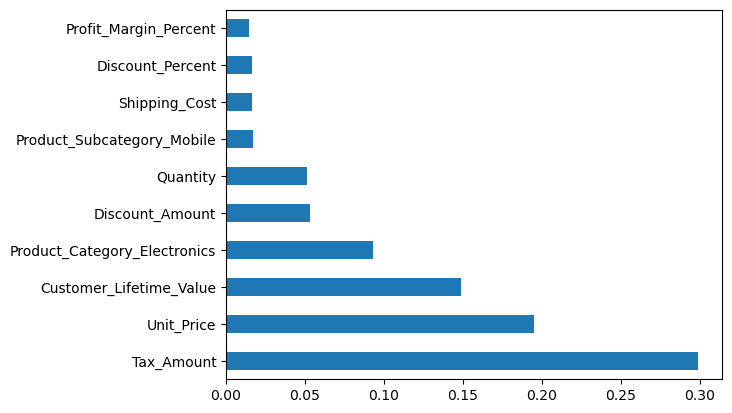

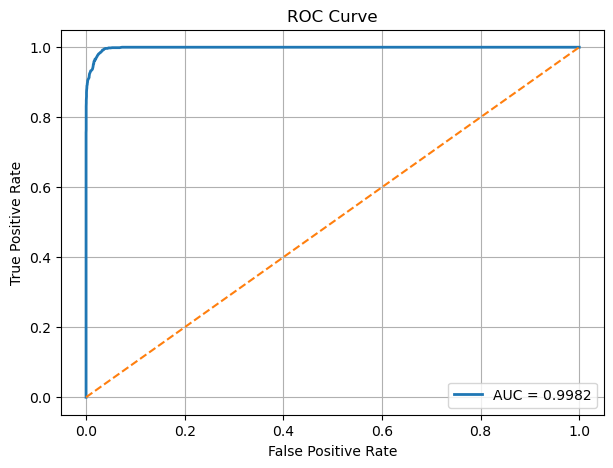

OOB Score: 98.0 %
OOB Error: 2.0 %
ROC-AUC Score: 0.9982


In [42]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100,criterion='gini', oob_score=True)
print(clf)
 
#Creating the model on Training Data
RF=clf.fit(X_train,y_train)
prediction=RF.predict(X_test)

#Measuring accuracy on Testing Data
from sklearn import metrics
print(metrics.classification_report(y_test, prediction))
print(metrics.confusion_matrix(y_test, prediction)) 
#Plotting the feature importance for Top 10 most important columns
%matplotlib inline
feature_importances = pd.Series(RF.feature_importances_, index=predictors)
feature_importances.nlargest(10).plot(kind='barh')
 
#Printing some sample values of prediction
TestingDataResults=pd.DataFrame(data=X_test, columns=predictors)
TestingDataResults['cardio']=y_test
TestingDataResults['Prediction']=prediction
TestingDataResults.head()


from sklearn.metrics import roc_curve, roc_auc_score
y_prob = RF.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, linewidth=2, label=f'AUC = {auc:.4f}')
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()
OOBScore = RF.oob_score_
print("OOB Score:", round(OOBScore,2)*100,'%')
OOBError = 1 - OOBScore
print("OOB Error:", round(OOBError,2)*100,'%')
auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", round(auc, 4))

In [ ]:
#!pip install xgboost

In [ ]:
#import sys
#!{sys.executable} -m pip install xgboost

In [ ]:
#from xgboost import XGBClassifier

#print("XGBoost installed successfully!")

In [ ]:
#import sys
#print(sys.executable) 

In [ ]:
#import sys
#!{sys.executable} -m pip show xgboost

In [ ]:
#import sys
#print(sys.executable)

#!{sys.executable} -m pip list

## XGBoost Classifier

XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.08, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4501
           1       0.99      0.99      0.99      1499

    accuracy                           1.00      6000
   macro avg       0.

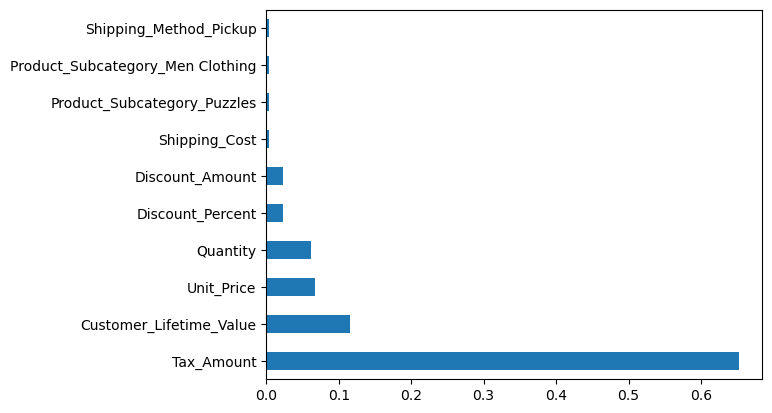

In [53]:
###### Xgboost Classification in Python #######
import pandas as pd 
from xgboost import XGBClassifier
clf=XGBClassifier(max_depth=4, learning_rate=0.08, n_estimators=300, objective='binary:logistic', booster='gbtree')
 
#Printing all the parameters of XGBoost
print(clf)
 
#Creating the model on Training Data                                                                                                         
XGB=clf.fit(X_train,y_train)
prediction=XGB.predict(X_test)
 
#Measuring accuracy on Testing Data
from sklearn import metrics
print(metrics.classification_report(y_test, prediction))
print(metrics.confusion_matrix(y_test, prediction))
 
#Plotting the feature importance for Top 10 most important columns
%matplotlib inline
feature_importances = pd.Series(XGB.feature_importances_, index=predictors)
feature_importances.nlargest(10).plot(kind='barh') 
 
#Printing some sample values of prediction
TestingDataResults=pd.DataFrame(data=X_test, columns=predictors)
TestingDataResults['TargetColumn']=y_test
TestingDataResults['Prediction']=prediction   
TestingDataResults.head()
print('Final Accuracy of the Model:',round(metrics.f1_score(y_test, prediction,average='weighted'),4)*100,"%")

## Ada Boost Classifier

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   learning_rate=0.1, n_estimators=600)
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      4501
           1       0.95      0.93      0.94      1499

    accuracy                           0.97      6000
   macro avg       0.97      0.96      0.96      6000
weighted avg       0.97      0.97      0.97      6000

[[4433   68]
 [  98 1401]]


,Quantity,Discount_Percent,Unit_Price,Discount_Amount,Shipping_Cost,Tax_Amount,Customer_Lifetime_Value,Profit_Margin_Percent,Product_Category_Beauty,Product_Category_Books,Product_Category_Electronics,Product_Category_Fashion,Product_Category_Groceries,Product_Category_Home & Kitchen,Product_Category_Sports,Product_Category_Toys,Product_Subcategory_Accessories,Product_Subcategory_Action Figures,Product_Subcategory_Appliances,Product_Subcategory_Bags,Product_Subcategory_Beverages,Product_Subcategory_Board Games,Product_Subcategory_Comics,Product_Subcategory_Cookware,Product_Subcategory_Dairy,Product_Subcategory_Decor,Product_Subcategory_Education,Product_Subcategory_Educational,Product_Subcategory_Equipment,Product_Subcategory_Fiction,Product_Subcategory_Fitness,Product_Subcategory_Fragrance,Product_Subcategory_Fresh Produce,Product_Subcategory_Furniture,Product_Subcategory_Haircare,Product_Subcategory_Headphones,Product_Subcategory_Laptop,Product_Subcategory_Makeup,Product_Subcategory_Men Clothing,Product_Subcategory_Mobile,Product_Subcategory_Non-Fiction,Product_Subcategory_Outdoor,Product_Subcategory_Puzzles,Product_Subcategory_Shoes,Product_Subcategory_Skincare,Product_Subcategory_Snacks,Product_Subcategory_Sportswear,Product_Subcategory_Women Clothing,Coupon_Used_No,Coupon_Used_Yes,Device_Type_Desktop,Device_Type_Mobile,Device_Type_Tablet,Shipping_Method_Express,Shipping_Method_Pickup,Shipping_Method_Same Day,Shipping_Method_Standard,Season_Autumn,Season_Spring,Season_Summer,Season_Winter,TargetColumn,Prediction
0,4.0,0.0,13.31,0.0,11.22,1.84,1212.52,28.84,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0,0
1,2.0,0.0,35.95,0.0,14.04,7.46,1404.32,37.75,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0
2,3.0,0.0,12.28,0.0,6.91,3.75,788.82,26.90,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0,0
3,2.0,0.0,27.48,0.0,2.28,4.56,2134.56,35.38,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0,0
4,4.0,35.0,417.14,584.0,8.43,85.43,5034.99,3.00,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1,1


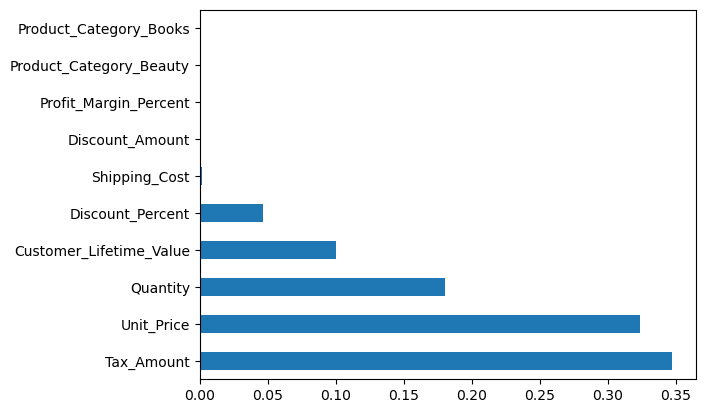

In [47]:
import pandas as pd
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
 
#Choosing Decision Tree with 1 level as the weak learner
DTC=DecisionTreeClassifier(max_depth=1)
clf = AdaBoostClassifier(n_estimators=600, estimator=DTC ,learning_rate=0.1)
 
#Printing all the parameters of Adaboost
print(clf)
 
#Creating the model on Training Data
AB=clf.fit(X_train,y_train)
prediction=AB.predict(X_test)
 
#Measuring accuracy on Testing Data
from sklearn import metrics
print(metrics.classification_report(y_test, prediction))
print(metrics.confusion_matrix(y_test, prediction))
 
#Plotting the feature importance for Top 10 most important columns
%matplotlib inline
feature_importances = pd.Series(AB.feature_importances_, index=predictors)
feature_importances.nlargest(10).plot(kind='barh')
 
#Printing some sample values of prediction
TestingDataResults=pd.DataFrame(data=X_test, columns=predictors)
TestingDataResults['TargetColumn']=y_test
TestingDataResults['Prediction']=prediction
TestingDataResults.head()

In [ ]:
import sys
print(sys.executable)

In [ ]:
import sys
!{sys.executable} -m pip install xgboost

In [ ]:
import sys
print(sys.executable)
!where python
!pip show xgboost

# Selected XGBoost Classification Model for Deployment

## Deploying on Sample Production Data

In [ ]:
3	5	125.84	18.88	18.83	36.46	5844.78	30.29	0	0	0	0	0	1	0	0	0	0	0	0	0	0	0	0	0	1	0	0	0	0	
0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	1	0	0	1	0	1	0	0	0	0	0	0	1	1

In [64]:
NewData = pd.DataFrame(data=
[
[3,10,18.44,5.53,15.50,2.91,2144.92,23.10,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,1],
[1,40,46.58,18.63,5.87,4.91,817.17,8.57,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,1],
[3,35,62.18,65.29,15.91,16.50,541.16,29.72,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,1],
[3,0,91.06,0.00,9.17,16.02,700.49,25.22,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,1,0,0,0,1],
[3,5,125.84,18.88,36.46,5844.78,2133.77,30.29,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,1,1]
],
 columns=predictors)


In [60]:
newX=NewData.values

In [61]:
XGB.predict(newX)

array([0, 0, 0, 0, 0])

In [65]:
def GenerateSurvialPred(inpData):
    newX=inpData.values
    # Making sure the new data is also Normalized using the same normalization PredictorScalerFit
    pred=XGB.predict(newX)
    inpData['Prediction']=pred
    return(inpData)

In [66]:
GenerateSurvialPred(inpData=NewData)

,Quantity,Discount_Percent,Unit_Price,Discount_Amount,Shipping_Cost,Tax_Amount,Customer_Lifetime_Value,Profit_Margin_Percent,Product_Category_Beauty,Product_Category_Books,Product_Category_Electronics,Product_Category_Fashion,Product_Category_Groceries,Product_Category_Home & Kitchen,Product_Category_Sports,Product_Category_Toys,Product_Subcategory_Accessories,Product_Subcategory_Action Figures,Product_Subcategory_Appliances,Product_Subcategory_Bags,Product_Subcategory_Beverages,Product_Subcategory_Board Games,Product_Subcategory_Comics,Product_Subcategory_Cookware,Product_Subcategory_Dairy,Product_Subcategory_Decor,Product_Subcategory_Education,Product_Subcategory_Educational,Product_Subcategory_Equipment,Product_Subcategory_Fiction,Product_Subcategory_Fitness,Product_Subcategory_Fragrance,Product_Subcategory_Fresh Produce,Product_Subcategory_Furniture,Product_Subcategory_Haircare,Product_Subcategory_Headphones,Product_Subcategory_Laptop,Product_Subcategory_Makeup,Product_Subcategory_Men Clothing,Product_Subcategory_Mobile,Product_Subcategory_Non-Fiction,Product_Subcategory_Outdoor,Product_Subcategory_Puzzles,Product_Subcategory_Shoes,Product_Subcategory_Skincare,Product_Subcategory_Snacks,Product_Subcategory_Sportswear,Product_Subcategory_Women Clothing,Coupon_Used_No,Coupon_Used_Yes,Device_Type_Desktop,Device_Type_Mobile,Device_Type_Tablet,Shipping_Method_Express,Shipping_Method_Pickup,Shipping_Method_Same Day,Shipping_Method_Standard,Season_Autumn,Season_Spring,Season_Summer,Season_Winter,Prediction
0,3,10,18.44,5.53,15.50,2.91,2144.92,23.10,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,1,0
1,1,40,46.58,18.63,5.87,4.91,817.17,8.57,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,1,0
2,3,35,62.18,65.29,15.91,16.50,541.16,29.72,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,1,0
3,3,0,91.06,0.00,9.17,16.02,700.49,25.22,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,1,0,0,0,1,0
4,3,5,125.84,18.88,36.46,5844.78,2133.77,30.29,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,1,1,1
